# Task 1: Potential problems in linear regression
## Section	Content
This task contains descriptions of 3 common issues in linear regression with discussions about their effect on interpretability, identification, and solutions. For each issue is an AI generated code chunk to produce visuals highlighting the associated description. 

### Plot code setup

In [26]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Set random seed for data generation
np.random.seed(42)
# Set consistent sample size
n = 150

# ── shared style ──────────────────────────────────────────────────────────────
COLORS = {
    "data":   "#2d6a4f",
    "fit":    "#d62828",
    "resid":  "#457b9d",
    "zero":   "#adb5bd",
    "funnel": "#e76f51",
}
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

fig = plt.figure(figsize=(14, 13))
fig.patch.set_facecolor("#f8f9fa")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)


<Figure size 1400x1300 with 0 Axes>

## Issue 1: Non-linearity
**Explanation**: Linear models assume that data is linear (straight line relationship between predictors and response). If the actual relationship is not linear, we can't make assumptions based on a linear model. 
**Identification**: We can try plotting residuals (true data vals- predicted) to look for trends. If there is a strong pattern in the residuals there is likely non-linearity in the data. 
**Solution**: If these is a non-linear trend in the residuals, a transformation should be done on predictors. Commonly this is a log transformation.

**Question**: Real data is frequently messy, and does not often have a linear relationship. What relationships might truly be linear without transformation?

**Answer**: Although uncommon in ecology, many mathematical relationships are truly linear. An example of this is mass and gravity, distance and time, perimeter and side length. These are relationships that are defined by being directly proportional to one other variable. 

**Plot**: A sinusoidal relationship fit with a straight line produces residuals with a strong wave pattern (1b), signaling the model is systematically wrong. After a polynomial transform captures the curve, residuals scatter randomly around zero (1c).

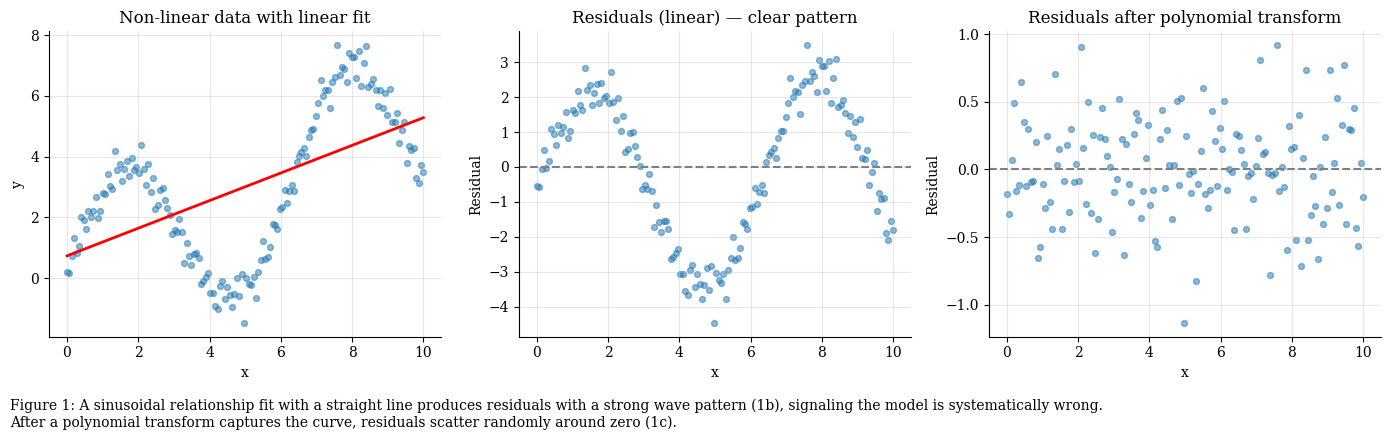

In [27]:
# ── 1. NON-LINEARITY ──────────────────────────────────────────────────────────
x = np.linspace(0, 10, n)
y = 3 * np.sin(x) + 0.5 * x + np.random.normal(0, 0.4, n)
 
lin_model = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred_lin = lin_model.predict(x.reshape(-1, 1))
resid_lin = y - y_pred_lin
 
poly = PolynomialFeatures(degree=6)
x_poly = poly.fit_transform(x.reshape(-1, 1))
poly_model = LinearRegression().fit(x_poly, y)
y_pred_poly = poly_model.predict(x_poly)
resid_poly = y - y_pred_poly
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
axes[0].scatter(x, y, alpha=0.5, s=18)
axes[0].plot(x, y_pred_lin, color="red", lw=2)
axes[0].set_title("Non-linear data with linear fit")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
 
axes[1].scatter(x, resid_lin, alpha=0.5, s=18)
axes[1].axhline(0, color="gray", lw=1.5, ls="--")
axes[1].set_title("Residuals (linear) — clear pattern")
axes[1].set_xlabel("x"); axes[1].set_ylabel("Residual")
 
axes[2].scatter(x, resid_poly, alpha=0.5, s=18)
axes[2].axhline(0, color="gray", lw=1.5, ls="--")
axes[2].set_title("Residuals after polynomial transform")
axes[2].set_xlabel("x"); axes[2].set_ylabel("Residual")
 
plt.tight_layout()
plt.figtext(0.01, -0.08, "Figure 1: A sinusoidal relationship fit with a straight line produces residuals with a strong wave pattern (1b), signaling the model is systematically wrong. \nAfter a polynomial transform captures the curve, residuals scatter randomly around zero (1c).")
plt.show()
 

## Issue 2: Correlation of error terms
**Explanation:** We assume in a linear model that the error terms are not related to each other. If they are in fact related, then there is a problem with the error estimate. Confidence and prediction intervals would be too small in this case because estimated standard errors underestimate the true standard errors, which falsely inflate our confidence in a model. 
**Identification:** This frequently occurs with time series data, where observations from similar time points will have positively correlated errors, where you might see tracking in residuals. Similarly with non-linearity in data, you can plot residuals over observations to understand trends or tracking between points. 
**Solution:** Much of the time accounting for this in time series data involves modifying the study design to try to minimize potential correlation of error. 

**Question:** What is an example of a natural study design that without minimizing for correlation of error terms would have uninterprettable results?

**Answer:** This actually occurs a lot in policy studies. An example of this is difference-in-difference policy analysis. Without correctering for data clusters and temporal autocorrelation, the results would be extremely biased, treating units as seperate when they are not independent. 

**Plot:** 


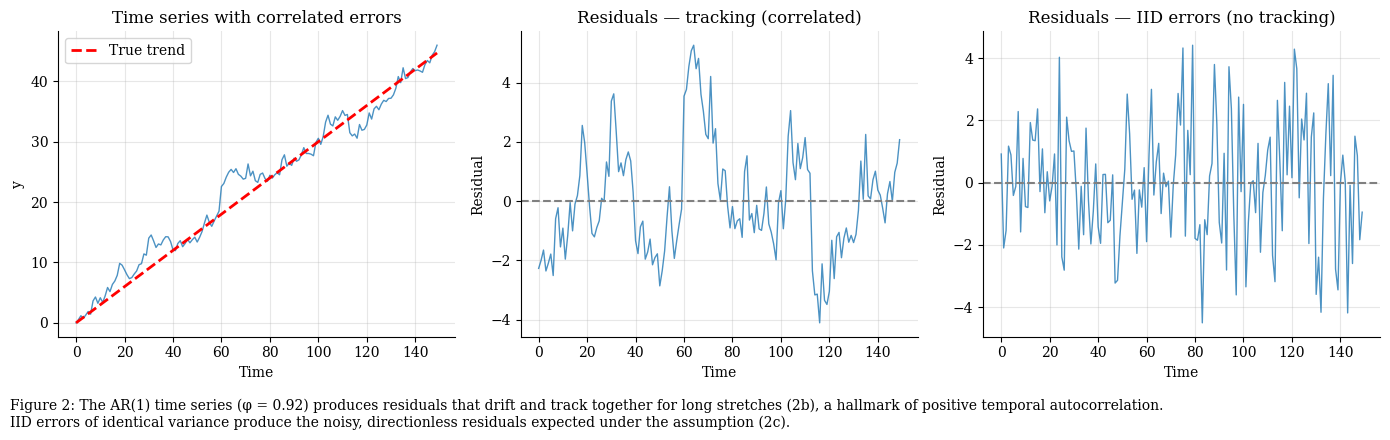

In [28]:

# ── 2. CORRELATED ERRORS (time series) ────────────────────────────────────────
t = np.arange(n)
trend = 0.3 * t
 
phi = 0.92
eps_corr = np.zeros(n)
for i in range(1, n):
    eps_corr[i] = phi * eps_corr[i-1] + np.random.normal(0, 1)
 
eps_iid = np.random.normal(0, np.std(eps_corr), n)
 
y_corr = trend + eps_corr
y_iid  = trend + eps_iid
 
def get_residuals(t, y):
    m = LinearRegression().fit(t.reshape(-1, 1), y)
    return y - m.predict(t.reshape(-1, 1))
 
resid_corr = get_residuals(t, y_corr)
resid_iid  = get_residuals(t, y_iid)
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
axes[0].plot(t, y_corr, lw=1, alpha=0.8)
axes[0].plot(t, trend, color="red", lw=2, ls="--", label="True trend")
axes[0].set_title("Time series with correlated errors")
axes[0].set_xlabel("Time"); axes[0].set_ylabel("y")
axes[0].legend()
 
axes[1].plot(t, resid_corr, lw=1, alpha=0.8)
axes[1].axhline(0, color="gray", lw=1.5, ls="--")
axes[1].set_title("Residuals — tracking (correlated)")
axes[1].set_xlabel("Time"); axes[1].set_ylabel("Residual")
 
axes[2].plot(t, resid_iid, lw=1, alpha=0.8)
axes[2].axhline(0, color="gray", lw=1.5, ls="--")
axes[2].set_title("Residuals — IID errors (no tracking)")
axes[2].set_xlabel("Time"); axes[2].set_ylabel("Residual")
 
plt.tight_layout()
plt.figtext(0.01, -0.08, "Figure 2: The AR(1) time series (φ = 0.92) produces residuals that drift and track together for long stretches (2b), a hallmark of positive temporal autocorrelation. \nIID errors of identical variance produce the noisy, directionless residuals expected under the assumption (2c).")
plt.show()


## Issue 3: Non-constant variance in error terms

**Explanation:** Linear models also assume that the errors have constant variance, which is infrequently met in real data. This similarly affects the certainty estimates in standard errors, confidence intervals, and hypothesis testing, so it is important to account for heteroscedasticity. 

**Identification:** This is often done by plotting the residuals, where a funnel shape in the residuals would indicate heteroscedasticity. 

**Solution:** This typically looks like transforming the response variable using a log or square root to normalize variance. 

**Question:** Sometimes outcome variable data is too messy to be normalized by log or square root transformations. What are the next steps in identifying non-constant variance in error terms after trying these transformations. At what point do you just need more data?

**Answer:** The simplest next step is to move past a linear model method, or to model residual variance directly. An example of this could be a weighted least squares regression- which gives lower variance observations more weight in determining coefficients.

**Plot:**

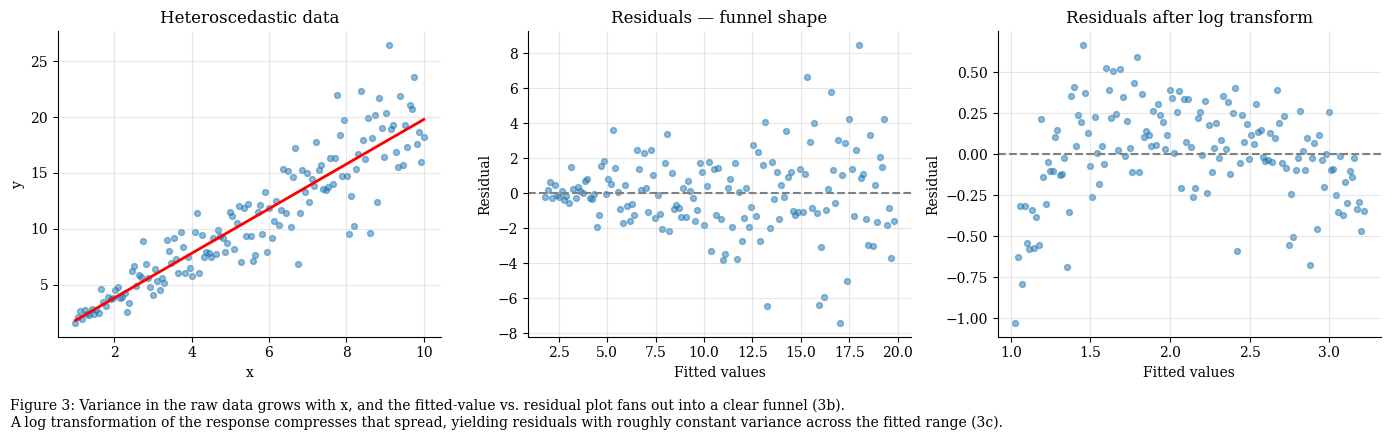

In [29]:

# ── 3. HETEROSCEDASTICITY ─────────────────────────────────────────────────────
x = np.linspace(1, 10, n)
y = 2 * x + np.random.normal(0, 0.4 * x, n)
y_log = np.log(y - y.min() + 1)
 
def fit_and_residuals(x, y):
    m = LinearRegression().fit(x.reshape(-1, 1), y)
    pred = m.predict(x.reshape(-1, 1))
    return pred, y - pred
 
pred, resid         = fit_and_residuals(x, y)
pred_log, resid_log = fit_and_residuals(x, y_log)
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
axes[0].scatter(x, y, alpha=0.5, s=18)
axes[0].plot(x, pred, color="red", lw=2)
axes[0].set_title("Heteroscedastic data")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
 
axes[1].scatter(pred, resid, alpha=0.5, s=18)
axes[1].axhline(0, color="gray", lw=1.5, ls="--")
axes[1].set_title("Residuals — funnel shape")
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("Residual")
 
axes[2].scatter(pred_log, resid_log, alpha=0.5, s=18)
axes[2].axhline(0, color="gray", lw=1.5, ls="--")
axes[2].set_title("Residuals after log transform")
axes[2].set_xlabel("Fitted values"); axes[2].set_ylabel("Residual")
 
plt.tight_layout()
plt.figtext(0.01, -0.08, "Figure 3: Variance in the raw data grows with x, and the fitted-value vs. residual plot fans out into a clear funnel (3b). \nA log transformation of the response compresses that spread, yielding residuals with roughly constant variance across the fitted range (3c).")
plt.show()

## Generative AI reflection
I used Claude to generate input data and plot outputs. I prompted it by giving my explanations of the issues and the directions given for what should be output. This took one prompt and output code with all its necessary packages, and did not result in any logically false outputs that I had to change. The only thing I added to improve the output was directly adding the figure caption it generated to the plot itself. 